# RoPE (Rotary Position Embedding) Tutorial

HuggingFace transformers의 vanilla RoPE 구현을 그대로 사용하여 위치 인코딩이 어떻게 동작하는지 단계별로 체험합니다.

**참고**: `transformers/models/llama/modeling_llama.py`

### 핵심 수학
- `inv_freq[i] = 1 / (base ^ (2i / dim))` — 각 dimension pair마다 다른 주파수
- `θ(pos, i) = pos × inv_freq[i]` — 위치에 비례하는 회전 각도
- `[x1', x2'] = [x1·cos(θ) - x2·sin(θ), x1·sin(θ) + x2·cos(θ)]` — 2D 회전

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline

## 1. HuggingFace transformers RoPE 핵심 함수들

`LlamaRotaryEmbedding`에서 vanilla RoPE 핵심만 추출한 코드입니다. 수학은 100% 동일합니다.

In [2]:
def rotate_half(x):
    """Rotates half the hidden dims of the input."""
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(q, k, cos, sin, position_ids=None, unsqueeze_dim=1):
    """Applies Rotary Position Embedding to the query and key tensors.

    q, k: [batch, num_heads, seq_len, head_dim]
    cos, sin: [batch, seq_len, head_dim]
    unsqueeze_dim=1 -> [batch, 1, seq_len, head_dim] for broadcast
    """
    cos = cos.unsqueeze(unsqueeze_dim)
    sin = sin.unsqueeze(unsqueeze_dim)
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed, k_embed

### `rotate_half` 동작 확인

`[x1, x2, x3, x4, x5, x6, x7, x8]` → `[-x5, -x6, -x7, -x8, x1, x2, x3, x4]`

이렇게 하면 `x * cos + rotate_half(x) * sin`으로 모든 dimension pair에 대해 동시에 2D 회전을 적용할 수 있습니다.

In [3]:
# rotate_half test
x = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
print(f"Original:     {x.tolist()}")
print(f"rotate_half:  {rotate_half(x).tolist()}")
print()

# Verify 2D rotation formula for a pair of dimensions (dim 0,1)
theta1 = 0.5  # rotation angle in radians
theta2 = 1.0  # rotation angle in radians
x_pair = torch.tensor([3.0, 7.0, 1.0, 4.0])  # (x1, x2, x3, x4)
# Apply rotation matrix to the pair (x1, x2, x3, x4)
x1_rot = x_pair[0] * math.cos(theta1) - x_pair[2] * math.sin(theta1)
x2_rot = x_pair[1] * math.cos(theta2) - x_pair[3] * math.sin(theta2)
x3_rot = x_pair[2] * math.cos(theta1) + x_pair[0] * math.sin(theta1)
x4_rot = x_pair[3] * math.cos(theta2) + x_pair[1] * math.sin(theta2)
print(f"Direct rotation matrix: [{x1_rot:.4f}, {x2_rot:.4f}, {x3_rot:.4f}, {x4_rot:.4f}]")

# rotate_half trick for the same result
x_full = torch.tensor([3.0, 7.0, 1.0, 4.0])  # dim=4 case
cos_t = torch.tensor([theta1, theta2, theta1, theta2]).cos()
sin_t = torch.tensor([theta1, theta2, theta1, theta2]).sin()
result = x_full * cos_t + rotate_half(x_full) * sin_t
print(f"rotate_half trick:      [{result[0]:.4f}, {result[1]:.4f}, {result[2]:.4f}, {result[3]:.4f}]")

Original:     [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
rotate_half:  [-5.0, -6.0, -7.0, -8.0, 1.0, 2.0, 3.0, 4.0]

Direct rotation matrix: [2.1533, 0.4162, 2.3159, 8.0515]
rotate_half trick:      [2.1533, 0.4162, 2.3159, 8.0515]


## 2. RotaryEmbedding 클래스

`LlamaRotaryEmbedding`에서 vanilla RoPE만 남긴 버전입니다.

In [4]:
class RotaryEmbedding(nn.Module):
    """HuggingFace transformers LlamaRotaryEmbedding (vanilla RoPE only).

    inv_freq[i] = 1 / (base ^ (2i / dim))
    freqs[pos, i] = pos * inv_freq[i]
    cos, sin = cos(freqs), sin(freqs)
    """

    def __init__(self, dim, max_position_embeddings=2048, base=10000, device=None):
        super().__init__()
        self.dim = dim
        self.max_position_embeddings = max_position_embeddings
        self.base = base

        # inv_freq: [dim // 2]
        inv_freq = 1.0 / (
            self.base ** (torch.arange(0, self.dim, 2, dtype=torch.int64).float() / self.dim)
        )
        self.register_buffer("inv_freq", inv_freq, persistent=False)

    @torch.no_grad()
    def forward(self, x, position_ids):
        # inv_freq_expanded: [batch, dim//2, 1]
        inv_freq_expanded = self.inv_freq[None, :, None].float().expand(
            position_ids.shape[0], -1, 1
        )
        # position_ids_expanded: [batch, 1, seq_len]
        position_ids_expanded = position_ids[:, None, :].float()

        # freqs: [batch, seq_len, dim//2]
        freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
        # emb: [batch, seq_len, dim]
        emb = torch.cat((freqs, freqs), dim=-1)
        cos = emb.cos()
        sin = emb.sin()

        return cos.to(dtype=x.dtype), sin.to(dtype=x.dtype)

## 3. Attention 모듈 (RoPE 적용)

HuggingFace transformers v4.45+ 구조를 따릅니다:
- **`RotaryEmbedding`은 Model 레벨**에서 1개만 생성
- Model이 cos/sin을 1번 계산하여 모든 Attention layer에 `position_embeddings`로 전달
- Attention은 `self.rotary_emb` 없이 받은 cos/sin만 사용

In [5]:
class RoPEAttention(nn.Module):
    def __init__(self, head_dim=16):
        super().__init__()
        self.head_dim = head_dim
        self.q_proj = nn.Linear(head_dim, head_dim, bias=False)
        self.k_proj = nn.Linear(head_dim, head_dim, bias=False)
        self.v_proj = nn.Linear(head_dim, head_dim, bias=False)
        self.o_proj = nn.Linear(head_dim, head_dim, bias=False)
        # NOTE: rotary_emb is NOT here

    def forward(self, x, position_embeddings):
        """
        x: [batch, seq_len, head_dim]
        position_embeddings: (cos, sin) from Model-level RotaryEmbedding
        """
        _, seq_len, _ = x.shape

        q = self.q_proj(x).unsqueeze(1)  # [batch, 1, seq_len, head_dim]
        k = self.k_proj(x).unsqueeze(1)
        v = self.v_proj(x).unsqueeze(1)

        # RoPE: unpack pre-computed cos, sin
        cos, sin = position_embeddings
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        # Scaled Dot-Product Attention + Causal Mask
        scale = math.sqrt(self.head_dim)
        attn_weights = torch.matmul(q, k.transpose(-2, -1)) / scale
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool), diagonal=1)
        attn_weights = attn_weights.masked_fill(causal_mask, float("-inf"))
        attn_weights = F.softmax(attn_weights, dim=-1)

        attn_output = torch.matmul(attn_weights, v).squeeze(1)
        attn_output = self.o_proj(attn_output)

        return attn_output, attn_weights.squeeze(1)


class LLM(nn.Module):
    def __init__(self, head_dim=16, num_layers=2, max_position_embeddings=128):
        super().__init__()
        self.rotary_emb = RotaryEmbedding(dim=head_dim, max_position_embeddings=max_position_embeddings)
        self.layers = nn.ModuleList([RoPEAttention(head_dim=head_dim) for _ in range(num_layers)])

    def forward(self, x):
        batch, seq_len, _ = x.shape
        position_ids = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch, -1)

        cos, sin = self.rotary_emb(x, position_ids)

        all_attn_weights = []
        for layer in self.layers:
            x, attn_weights = layer(x, (cos, sin))
            all_attn_weights.append(attn_weights)

        return x, all_attn_weights

### Model 실행 & 각 Layer의 Attention Weight 확인

`RoPEModel`이 `RotaryEmbedding` 1개로 cos/sin을 계산하고, 2개 layer에 동일하게 전달합니다.

In [6]:
model = LLM(head_dim=16, num_layers=2)
rope = RotaryEmbedding(dim=16, max_position_embeddings=128)

## 4. 상대 위치 인코딩 검증

RoPE의 핵심 성질: **동일한 벡터**를 모든 위치에 배치하면, `q_m · k_n`의 dot product는 **상대 거리 |m-n|에만** 의존합니다.

$$q_m^T k_n = f(x_q, x_k, m-n)$$

In [7]:
seq_len = 3
head_dim = 16
q = torch.randn(1, seq_len, head_dim)
k = torch.randn(1, seq_len, head_dim)

position_ids = torch.arange(seq_len).unsqueeze(0)
position_ids_ = position_ids + 5  # 5 positions ahead
cos, sin = rope(q, position_ids)
cos_, sin_ = rope(q, position_ids_)

q_4d, k_4d = q.unsqueeze(1), k.unsqueeze(1)
q_rot, k_rot = apply_rotary_pos_emb(q_4d, k_4d, cos, sin)
q_rot_, k_rot_ = apply_rotary_pos_emb(q_4d, k_4d, cos_, sin_)

print("Rotated vectors:")
print(torch.isclose(q_rot, q_rot_))


Rotated vectors:
tensor([[[[False, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False],
          [False, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False],
          [False, False, False, False, False, False, False, False, False, False,
           False, False, False, False, False, False]]]])


In [8]:
# dot product matrix
dots = torch.matmul(q_rot, k_rot.transpose(-2, -1)).squeeze()
dots_ = torch.matmul(q_rot_, k_rot_.transpose(-2, -1)).squeeze()
print("Q·K dot products (same vector at all positions, RoPE applied):")
print(torch.isclose(dots, dots_))

Q·K dot products (same vector at all positions, RoPE applied):
tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])


## 5. Visualization: 위치별 회전 시각화

4개의 플롯으로 RoPE의 동작을 시각적으로 이해합니다.

### Plot (1): Rotation Angle per Position

각 dimension pair는 서로 다른 주파수로 회전합니다. pair 0은 가장 빠르게, pair 7은 가장 느리게 회전합니다.

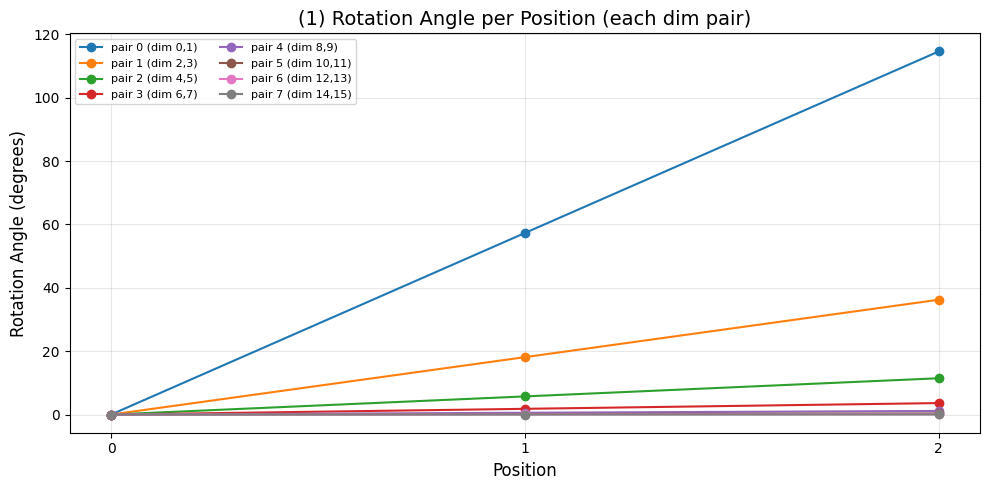

In [9]:
num_pairs = head_dim // 2
inv_freq_np = rope.inv_freq.numpy()

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(num_pairs):
    angles = (np.arange(seq_len) * inv_freq_np[i])
    ax.plot(range(seq_len), np.degrees(angles), "o-", label=f"pair {i} (dim {2*i},{2*i+1})")
ax.set_xlabel("Position", fontsize=12)
ax.set_ylabel("Rotation Angle (degrees)", fontsize=12)
ax.set_title("(1) Rotation Angle per Position (each dim pair)", fontsize=14)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(seq_len))
plt.tight_layout()
plt.show()

### Plot (2): 2D Rotation of unit vector (1,0)

단위벡터 `(1, 0)`이 각 position에서 어떻게 회전되는지 보여줍니다. 투명도가 높을수록 뒤쪽 position입니다.
- **pair 0** (빨강): 빠르게 회전 — position마다 큰 각도
- **pair 3** (초록): 중간 속도
- **pair 7** (파랑): 거의 회전하지 않음

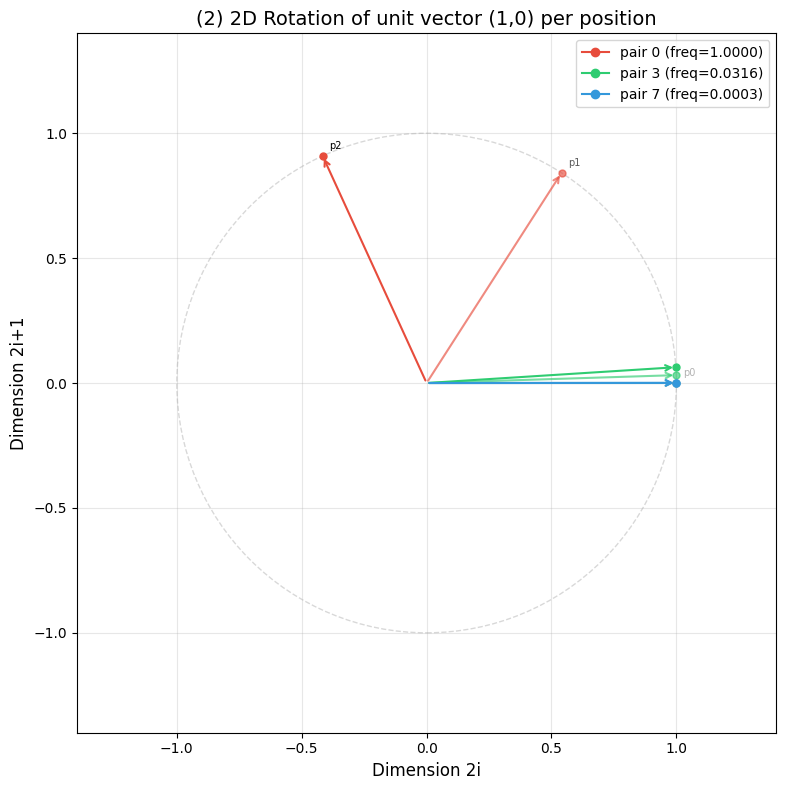

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
pairs_to_show = [0, 3, 7]
colors = ["#e74c3c", "#2ecc71", "#3498db"]

for idx, pair_i in enumerate(pairs_to_show):
    freq = inv_freq_np[pair_i]
    for pos in range(seq_len):
        theta = pos * freq
        x_rot = math.cos(theta)
        y_rot = math.sin(theta)
        alpha = 0.3 + 0.7 * (pos / (seq_len - 1))
        ax.annotate("", xy=(x_rot, y_rot), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color=colors[idx], alpha=alpha, lw=1.5))
        ax.plot(x_rot, y_rot, "o", color=colors[idx], alpha=alpha, markersize=5)
        if idx == 0:
            ax.annotate(f"p{pos}", (x_rot, y_rot), textcoords="offset points",
                         xytext=(5, 5), fontsize=7, alpha=alpha)

for idx, pair_i in enumerate(pairs_to_show):
    ax.plot([], [], "o-", color=colors[idx], label=f"pair {pair_i} (freq={inv_freq_np[pair_i]:.4f})")

circle = plt.Circle((0, 0), 1, fill=False, color="gray", linestyle="--", alpha=0.3)
ax.add_patch(circle)
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal")
ax.set_xlabel("Dimension 2i", fontsize=12)
ax.set_ylabel("Dimension 2i+1", fontsize=12)
ax.set_title("(2) 2D Rotation of unit vector (1,0) per position", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()